# Quality Control Example

This notebook demonstrates the `dynamic_foraging_processing.qc` module: the
**metrics** that can be gathered and the **plots** that can be produced from the
trial table (the precomputed `side_bias` column).

It uses **synthetic data** (no dataset loading) so it runs anywhere, mirroring
the arrays used in the unit tests. Swap in a real session's `side_bias` (e.g. the
column from `TrialTableBuilder.build()`) to use it for real.

## Create synthetic data

A random per-trial choice sequence plus the optional per-trial context the
side-bias figure can display (reward history, reward probabilities, autowater,
go-cue times), assembled into a `trials` DataFrame using the same column names
the QC entry points expect. None of this needs a dataset.

In [3]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(0)
n_trials = 200

# Choice per trial: 0 left, 1 right, 2 ignore (slightly right-biased here).
animal_response = rng.choice([0, 1, 2], size=n_trials, p=[0.4, 0.5, 0.1])

# Per-trial side bias from the trial table (right minus left). Computed over a
# sliding window, so it is nan only after many consecutive non-responses;
# synthetic here as a mild rightward bias.
side_bias = np.clip(rng.normal(0.15, 0.2, n_trials), -1.0, 1.0)

# Per-trial context (synthetic), one column each.
rewarded_left = (animal_response == 0) & (rng.random(n_trials) < 0.5)
rewarded_right = (animal_response == 1) & (rng.random(n_trials) < 0.5)
autowater_left = np.zeros(n_trials, int)
autowater_right = np.zeros(n_trials, int)
reward_probability_left = np.full(n_trials, 0.4)
reward_probability_right = np.full(n_trials, 0.6)
go_cue_times = np.arange(n_trials, dtype=float)

# Assemble the trials table. Column names match what the QC entry points expect
# (see `_COLUMNS` in qc.processed.results); a real session uses the table from
# `TrialTableBuilder.build()`.
trials = pd.DataFrame(
    {
        "animal_response": animal_response,
        "side_bias": side_bias,
        "rewarded_historyL": rewarded_left,
        "rewarded_historyR": rewarded_right,
        "auto_waterL": autowater_left,
        "auto_waterR": autowater_right,
        "reward_probabilityL": reward_probability_left,
        "reward_probabilityR": reward_probability_right,
        "goCue_start_time": go_cue_times,
    }
)

print("n trials:", n_trials)
print("left  (0):", int(np.sum(animal_response == 0)))
print("right (1):", int(np.sum(animal_response == 1)))
print("ignore(2):", int(np.sum(animal_response == 2)))
print("columns:", list(trials.columns))

n trials: 200
left  (0): 70
right (1): 100
ignore(2): 30
columns: ['animal_response', 'side_bias', 'rewarded_historyL', 'rewarded_historyR', 'auto_waterL', 'auto_waterR', 'reward_probabilityL', 'reward_probabilityR', 'goCue_start_time']


## Metrics from the trial table

### Average side bias
The `side_bias` column is precomputed per trial in the trial table. The QC check averages it over the session; `abs(mean) < 0.5` passes.

In [4]:
mean_bias = round(float(np.nanmean(side_bias)), 3)
print(f"average side bias: {mean_bias}")

average side bias: 0.132


### As a QC result / metric
`side_bias_result` averages the `side_bias` column into a `QCResult` (pass when
`abs(mean) < 0.5`), which converts to an `aind_data_schema` `QCMetric`.

In [5]:
from dynamic_foraging_processing.qc import side_bias_result

result = side_bias_result(side_bias)
print("name:   ", result.name)
print("value:  ", result.value)
print("passed: ", result.passed)
print("tags:   ", result.tags)

metric = result.to_metric()
metric

name:    average side bias
value:   0.132
passed:  True
tags:    {'behavior': 'average side bias'}


QCMetric(object_type='QC metric', name='average side bias', modality=_Behavior(name='Behavior', abbreviation='behavior'), stage='Raw data', value=0.132, status_history=[QCStatus(object_type='QC status', evaluator='Automated', status='Pass', timestamp=datetime.datetime(2026, 6, 23, 16, 24, 27, 352495, tzinfo=zoneinfo.ZoneInfo(key='America/Los_Angeles')))], description='Average side bias across the session (right is positive).', reference='side_bias.png', tags={'behavior': 'average side bias'}, evaluated_assets=None)

## Plot: side-bias figure

`plot_side_bias` writes a four-panel `side_bias.png` into a results folder: the
per-trial `side_bias` trace, lickspout position, per-trial behavior raster, and
reward probabilities. The bias panel is driven by the `side_bias` column; the
remaining panels are populated from the optional per-trial context created above.

In [6]:
from pathlib import Path

from dynamic_foraging_processing.qc import plot_side_bias

results_folder = Path("qc_results")
results_folder.mkdir(exist_ok=True)

plot_side_bias(
    animal_response,
    side_bias,
    str(results_folder),
    rewarded_left=rewarded_left,
    rewarded_right=rewarded_right,
    reward_probability_left=reward_probability_left,
    reward_probability_right=reward_probability_right,
    go_cue_times=go_cue_times,
    autowater_left=autowater_left,
    autowater_right=autowater_right,
)

'side_bias.png'

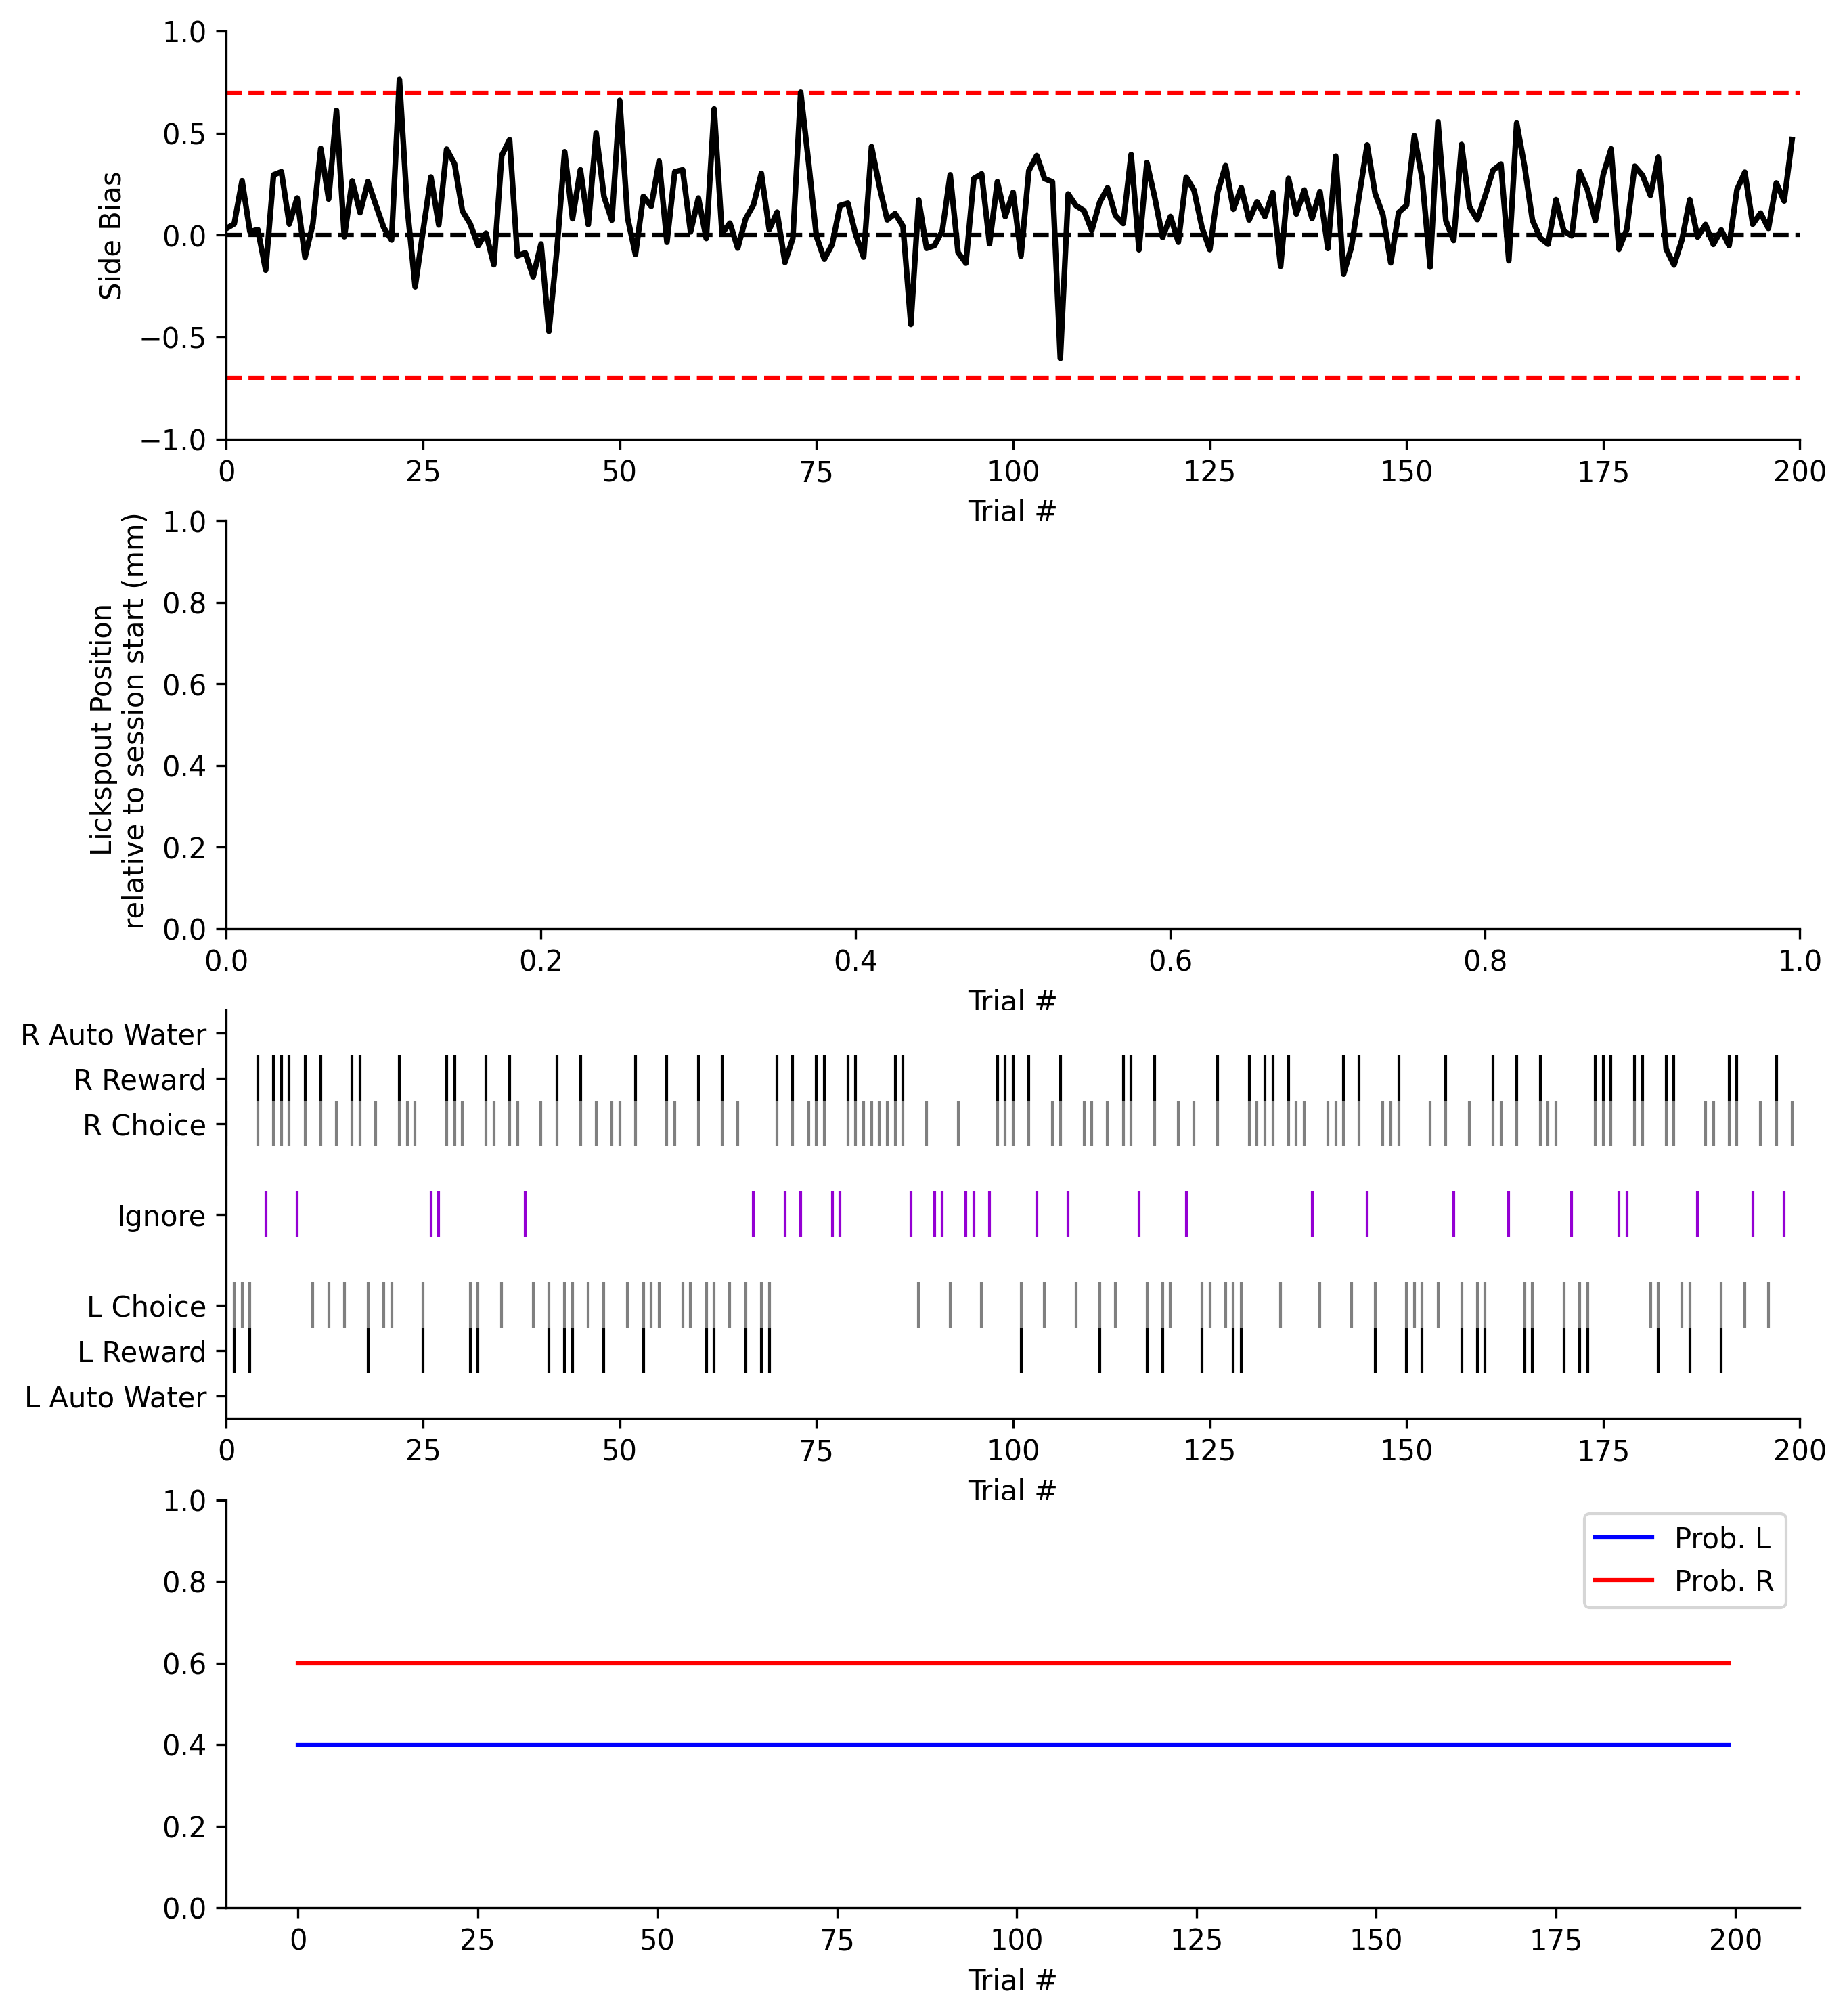

In [7]:
from IPython.display import Image

Image(filename=str(results_folder / "side_bias.png"))

## Metrics: inter-lick intervals

The lick metrics come from the per-port lick timestamps rather than the trial
table. `lick_interval_results` runs `calculate_lick_intervals` and returns four
`QCResult` objects — the percentage of left, right, and cross-side intervals
below the physiological threshold, plus an artifact percentage. Left/right/cross
pass when `< 10`; the artifact percent passes when `< 1`.

In [8]:
# Synthetic per-port lick timestamps (s). Real sessions would use the lick
# times pulled from the NWB file; here we just scatter licks across the session.
rng_licks = np.random.default_rng(1)
left_lick_times = np.sort(rng_licks.uniform(0, n_trials, size=400))
right_lick_times = np.sort(rng_licks.uniform(0, n_trials, size=500))

print("left licks: ", len(left_lick_times))
print("right licks:", len(right_lick_times))

left licks:  400
right licks: 500


In [9]:
from dynamic_foraging_processing.qc import lick_interval_results

lick_results = lick_interval_results(left_lick_times, right_lick_times)
for r in lick_results:
    print(f"{r.name:30s} value={r.value:7.3f}  passed={r.passed}")

Left Lick Interval (%)         value=  9.270  passed=True
Right Lick Interval (%)        value= 12.420  passed=False
Cross Side Lick Interval (%)   value=  9.890  passed=True
Artifact Percent (%)           value=  0.445  passed=True


## Plot: inter-lick-interval histogram

`plot_lick_intervals` writes a five-panel `lick_intervals.png` into the results
folder: histograms of the inter-lick intervals for left licks, right licks,
left-to-right transitions, right-to-left transitions, and all licks combined.
Like the metrics above, it is driven purely by the left/right lick timestamps.

In [10]:
from dynamic_foraging_processing.qc import plot_lick_intervals

plot_lick_intervals(left_lick_times, right_lick_times, str(results_folder))

'lick_intervals.png'

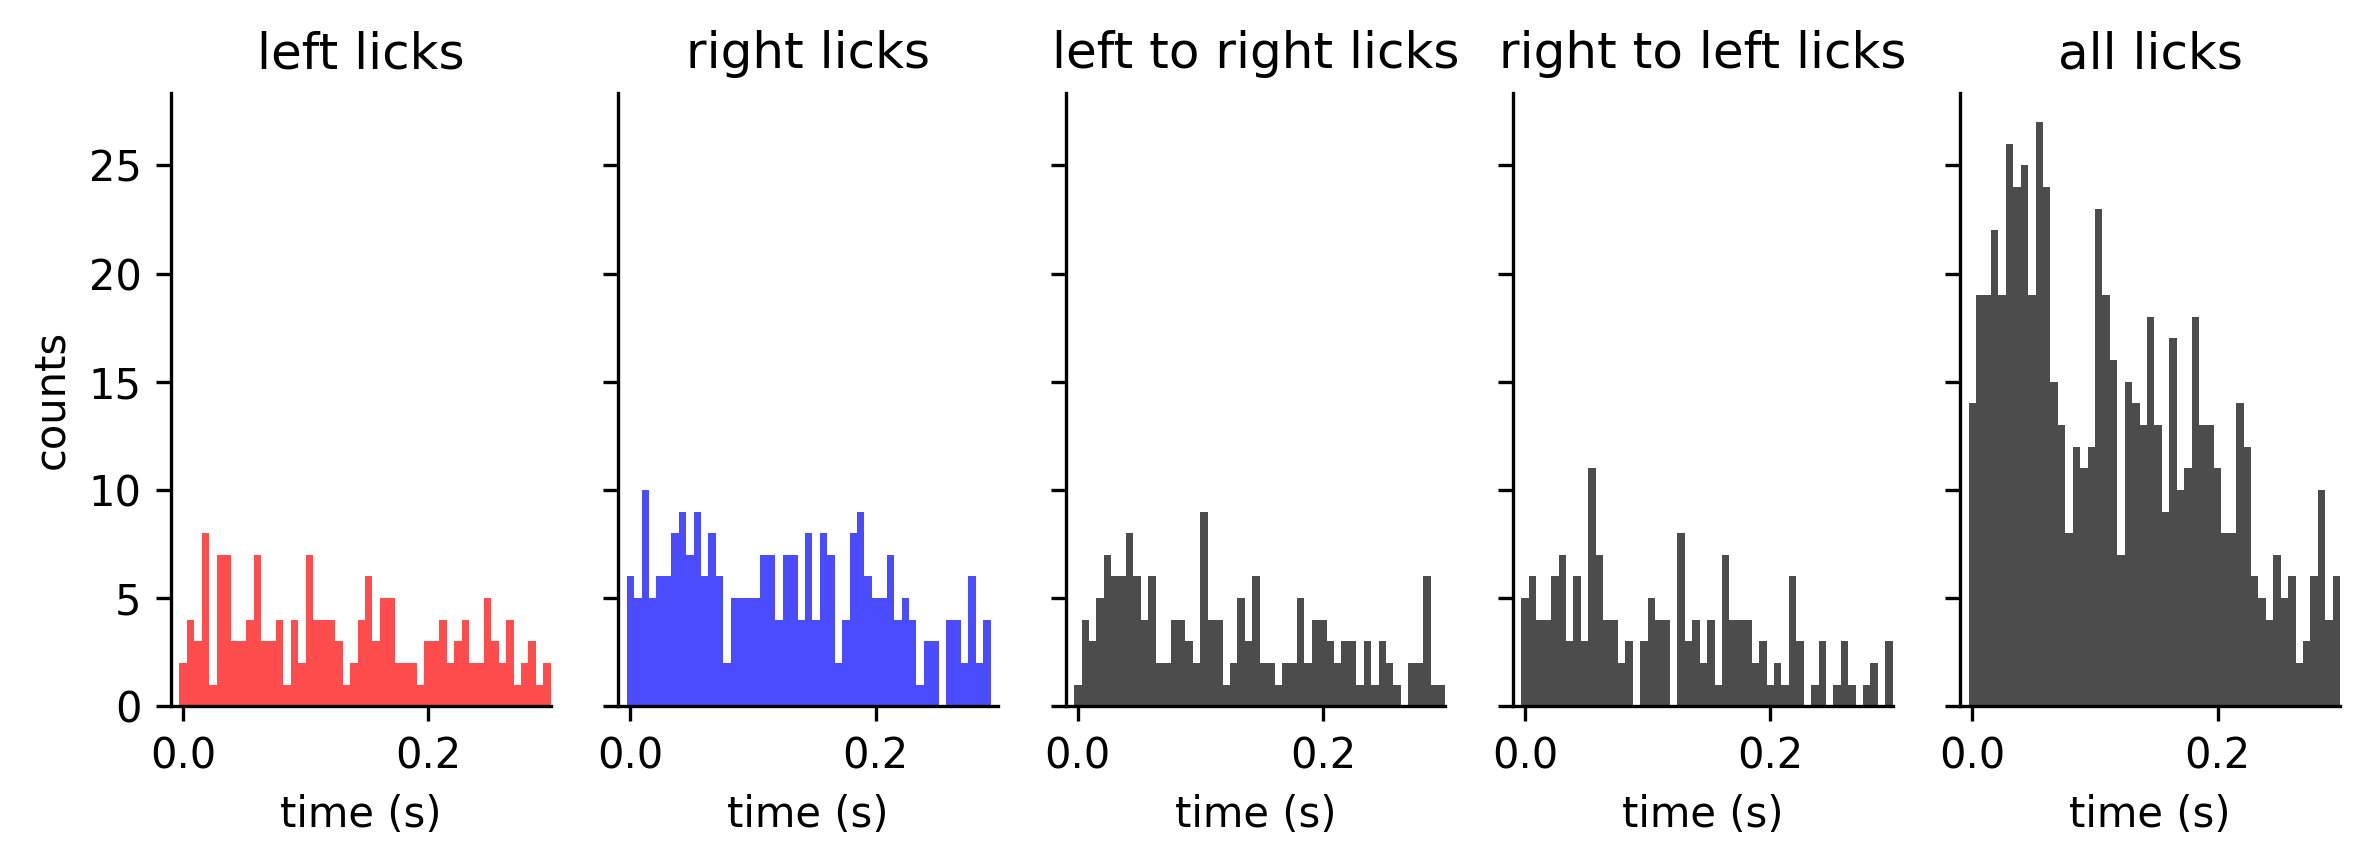

In [11]:
Image(filename=str(results_folder / "lick_intervals.png"))

## Assemble a `QualityControl` object

The individual checks above can be collected in one call: `behavior_qc_results`
takes the `trials` table plus the left/right lick-time arrays and returns the
ordered list of `QCResult`s — the average side bias followed by the four
inter-lick-interval checks. `to_metrics` converts them to schema `QCMetric`s, and
`build_quality_control` assembles the final `QualityControl`. (Passing a
`results_folder` would also write the supporting plots; omitted here since the
cells above already produced them.)

In [12]:
from dynamic_foraging_processing.qc import (
    behavior_qc_results,
    build_quality_control,
    to_metrics,
)

# One call collects all five behavior results from the trials table plus the
# lick-time arrays: the average side bias and the four lick-interval checks.
behavior_results = behavior_qc_results(trials, left_lick_times, right_lick_times)
behavior_metrics = to_metrics(behavior_results)

quality_control = build_quality_control(behavior_metrics)
print("total metrics:", len(quality_control.metrics))
for m in quality_control.metrics:
    print(f"  - {m.name}: {m.status_history[-1].status}")
print("default grouping:", quality_control.default_grouping)
quality_control

total metrics: 5
  - average side bias: Pass
  - Left Lick Interval (%): Pass
  - Right Lick Interval (%): Fail
  - Cross Side Lick Interval (%): Pass
  - Artifact Percent (%): Pass
default grouping: ['behavior', 'test_suite']


QualityControl(object_type='Quality control', describedBy='https://raw.githubusercontent.com/AllenNeuralDynamics/aind-data-schema/main/src/aind_data_schema/core/quality_control.py', schema_version='2.4.2', metrics=[QCMetric(object_type='QC metric', name='average side bias', modality=_Behavior(name='Behavior', abbreviation='behavior'), stage='Raw data', value=0.132, status_history=[QCStatus(object_type='QC status', evaluator='Automated', status='Pass', timestamp=datetime.datetime(2026, 6, 23, 16, 24, 45, 236104, tzinfo=zoneinfo.ZoneInfo(key='America/Los_Angeles')))], description='Average side bias across the session (right is positive).', reference='side_bias.png', tags={'behavior': 'average side bias'}, evaluated_assets=None), QCMetric(object_type='QC metric', name='Left Lick Interval (%)', modality=_Behavior(name='Behavior', abbreviation='behavior'), stage='Raw data', value=9.27, status_history=[QCStatus(object_type='QC status', evaluator='Automated', status='Pass', timestamp=datetime